In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")
from src.graphs import PowerOf2EdgeGraph, Graph

import networkx as nx
import numpy as np
from qiskit.quantum_info import Operator
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np

import networkx as nx
import random

In [2]:
def generate_test_graphs(n_vertices, n_graphs=100):
    graphs = []
    while len(graphs) < n_graphs:
        g = nx.gnm_random_graph(n_vertices, random.randint(n_vertices, n_vertices*(n_vertices-1)//2))
        if nx.is_connected(g) and all(nx.is_isomorphic(g, h) == False for h in graphs):
            graphs.append(g)
    return graphs

test_graphs_8 = generate_test_graphs(8)
test_graphs_16 = generate_test_graphs(16)
test_graphs_32 = generate_test_graphs(32)

In [3]:
def trotterized_quantum_walk(graph, time, n_steps):
    edge_set = set(graph.edges())
    power_of_2_graph = PowerOf2EdgeGraph(edge_set)
    subgraphs = power_of_2_graph.subgraphs
    delta_t = time / n_steps
    
    n_qubits = power_of_2_graph.n_qubits
    n_states = 2**n_qubits
    time_evo_op = np.eye(n_states, dtype=complex)
    
    for _ in range(n_steps):
        for subgraph in subgraphs:
            # Create a mapping from subgraph nodes to indices
            node_to_index = {node: i for i, node in enumerate(subgraph.nodes())}
            subgraph_size = len(node_to_index)
            
            # Create the adjacency matrix for the subgraph
            adj_matrix = np.zeros((subgraph_size, subgraph_size), dtype=complex)
            for u, v in subgraph.edges():
                i, j = node_to_index[u], node_to_index[v]
                adj_matrix[i, j] = adj_matrix[j, i] = 1
            
            # Compute the unitary for the subgraph
            subgraph_unitary = expm(-1j * adj_matrix * delta_t)
            
            # Create the full unitary by embedding the subgraph unitary
            full_unitary = np.eye(n_states, dtype=complex)
            for i, node_i in enumerate(subgraph.nodes()):
                for j, node_j in enumerate(subgraph.nodes()):
                    full_unitary[node_i, node_j] = subgraph_unitary[i, j]
            
            time_evo_op = np.dot(full_unitary, time_evo_op)
    
    return Operator(time_evo_op)

def original_ctqw(graph, time):
    static_graph = Graph(set(graph.edges()))
    n_qubits = static_graph.n_qubits
    n_states = 2**n_qubits
    adj_matrix = nx.adjacency_matrix(graph).toarray()
    time_evo_op = expm(-1j * adj_matrix * time)
    
    # Pad the time evolution operator if necessary
    if time_evo_op.shape[0] < n_states:
        padded_op = np.eye(n_states, dtype=complex)
        padded_op[:time_evo_op.shape[0], :time_evo_op.shape[1]] = time_evo_op
        time_evo_op = padded_op
    
    return Operator(time_evo_op)

In [4]:
def compare_walks(graph, time, n_steps):
    trotterized_op = trotterized_quantum_walk(graph, time, n_steps)
    original_op = original_ctqw(graph, time)
    
    op_diff = trotterized_op - original_op
    return np.linalg.norm(op_diff.data, ord=2)

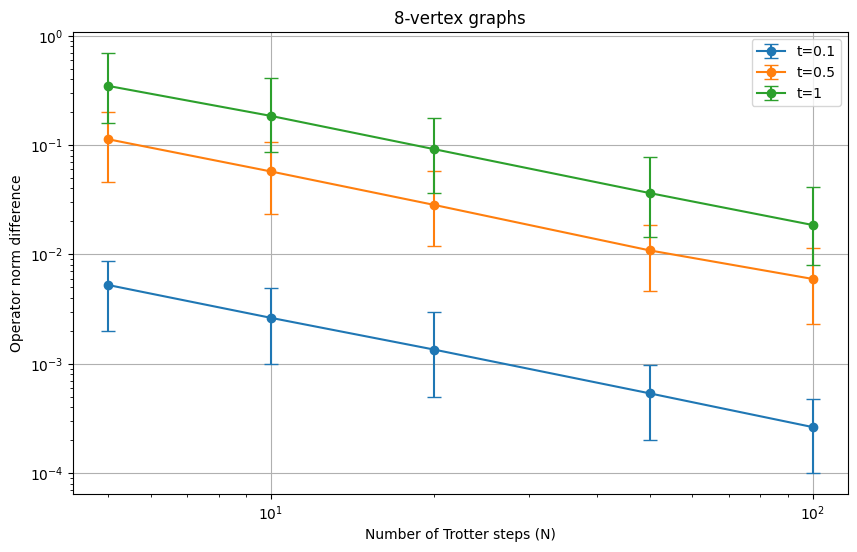

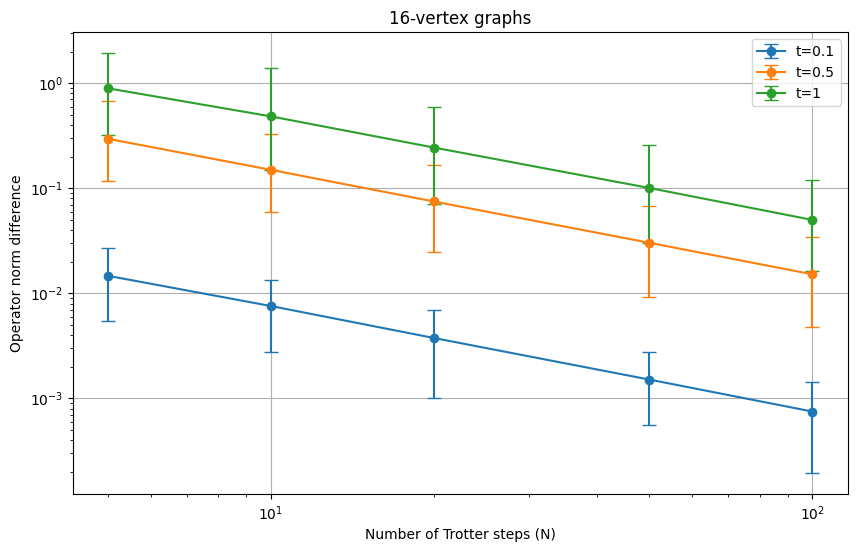

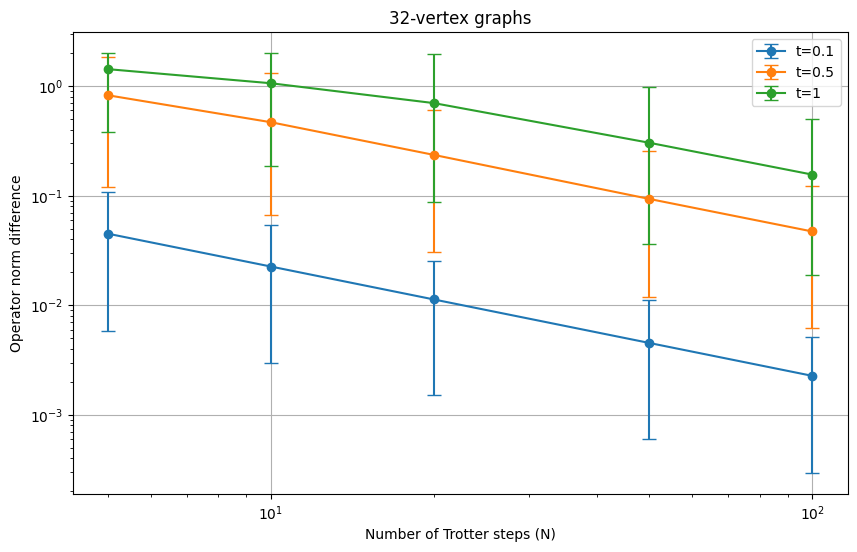

In [5]:
def plot_results(graphs, times, n_steps_list, title):
    results = {t: {N: [] for N in n_steps_list} for t in times}
    
    for graph in graphs:
        for t in times:
            for N in n_steps_list:
                diff = compare_walks(graph, t, N)
                results[t][N].append(diff)
    
    plt.figure(figsize=(10, 6))
    for t in times:
        N_values = sorted(n_steps_list)
        mean_diff = [np.mean(results[t][N]) for N in N_values]
        min_diff = [np.min(results[t][N]) for N in N_values]
        max_diff = [np.max(results[t][N]) for N in N_values]
        
        yerr_low = [m - min_d for m, min_d in zip(mean_diff, min_diff)]
        yerr_high = [max_d - m for m, max_d in zip(mean_diff, max_diff)]
        
        plt.errorbar(N_values, mean_diff, yerr=[yerr_low, yerr_high], 
                     fmt='-o', capsize=5, label=f't={t}')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Trotter steps (N)')
    plt.ylabel('Operator norm difference')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
# Generate plots
times = [0.1, 0.5, 1]
n_steps_list = [5, 10, 20, 50, 100]

plot_results(test_graphs_8, times, n_steps_list, '8-vertex graphs')
plot_results(test_graphs_16, times, n_steps_list, '16-vertex graphs')
plot_results(test_graphs_32, times, n_steps_list, '32-vertex graphs')